# Probability Calibration

For the past 17 lessons, we have built complex architectures, tuned hyperparameters, and audited our boundaries using Precision and Recall. However, there is a final, critical barrier to deploying models in highly regulated enterprise environments (like algorithmic trading, autonomous driving, or medical diagnosis).

If a doctor asks an AI, *"Does this patient have cancer?"* and the AI outputs `0.80`, the doctor assumes there is exactly an $80\%$ chance the patient has cancer. But **machine learning outputs are not true probabilities.** They are raw mathematical scores squashed between 0 and 1. If an uncalibrated model says "80%", the true real-world likelihood might only be 60%. Acting on that false confidence can be catastrophic.

In this expert-level lesson, we will mathematically audit and correct the "confidence" of our algorithms using **Probability Calibration**.

Calibration is the process of mathematically reshaping a model's output scores so that they perfectly align with real-world empirical probabilities. A model is considered perfectly calibrated if, out of 100 predictions where it predicted a $70\%$ probability, exactly 70 of those predictions were correct.

Let's set up our Python environment to audit an uncalibrated model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Mathematical Probability Calibration Environment Ready.")

✅ Mathematical Probability Calibration Environment Ready.


# 1. Why are Models Uncalibrated?

Different algorithms warp probabilities in completely different ways based on their underlying math:
* **Naive Bayes (Extreme Confidence)**: Because of its "naive" assumption that all features are independent, it multiplies probabilities together aggressively. It tends to push all scores to absolute $0.0$ or absolute $1.0$. It is fiercely overconfident.
* **Random Forests (Averaged Timidity)**: Because it averages the hard votes of 500 trees, it is incredibly rare for all 500 trees to perfectly agree. Therefore, it rarely outputs a $0.0$ or $1.0$. It pushes probabilities away from the extremes and toward the $0.5$ center.
* **Support Vector Machines (Margin Warping)**: SVMs do not natively output probabilities at all. They output the physical geometric distance from the margin. Forcing this distance into a Sigmoid curve mathematically distorts the probabilities.

# 2. Auditing the Math (The Reliability Diagram and Brier Score)

How do we mathematically prove a model is lying about its confidence? 

### The Reliability Curve
We take our Test Set predictions and group them into "bins" (e.g., all predictions between $0.70$ and $0.80$). We then calculate the *Actual Empirical Frequency* of Class 1 in that bin. We plot the Predicted Probability against the Actual Frequency. 
* A perfectly calibrated model forms a perfectly straight 45-degree diagonal line.

### The Brier Score (MSE for Probabilities)
We cannot use Accuracy or Log-Loss to measure calibration. We use the **Brier Score**, which is essentially the Mean Squared Error of the probability forecasts:
$$BS = \frac{1}{N} \sum_{i=1}^{N} (f_i - o_i)^2$$
* $f_i$ is the forecasted probability.
* $o_i$ is the actual outcome ($0$ or $1$).
* **A lower Brier Score means better calibration.**

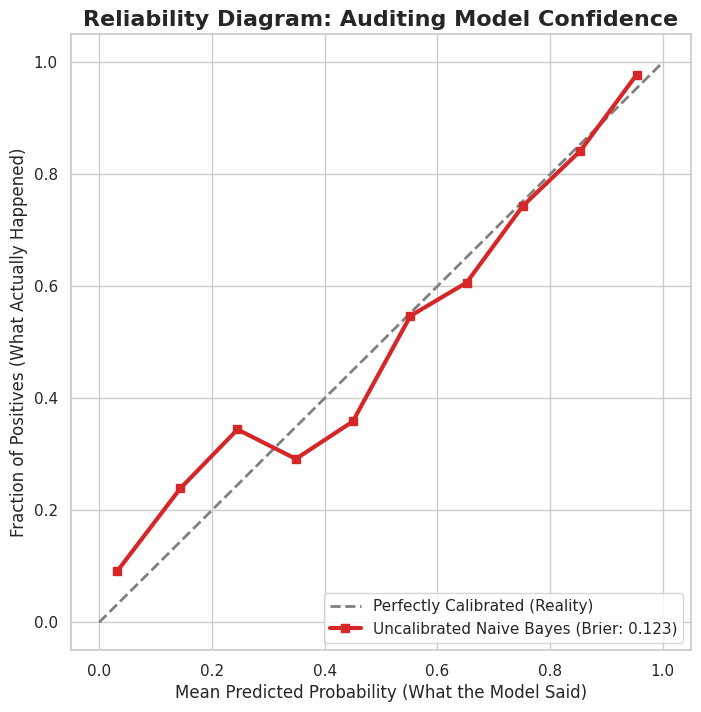

In [2]:
# 1. Simulate a corporate dataset (e.g., Medical Diagnosis)
X, y = make_classification(n_samples=5000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Train an notoriously uncalibrated model (Naive Bayes)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Extract raw probabilities
prob_uncalibrated = nb_model.predict_proba(X_test)[:, 1]

# 3. Calculate Reliability Curve Math
# We split the predictions into 10 bins
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_uncalibrated, n_bins=10)

# Calculate Brier Score
brier_uncalibrated = brier_score_loss(y_test, prob_uncalibrated)

# 4. Matplotlib Visualization
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Perfectly Calibrated (Reality)')
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='#d62728', linewidth=3, 
         label=f'Uncalibrated Naive Bayes (Brier: {brier_uncalibrated:.3f})')

plt.title("Reliability Diagram: Auditing Model Confidence", fontsize=16, fontweight='bold')
plt.xlabel("Mean Predicted Probability (What the Model Said)")
plt.ylabel("Fraction of Positives (What Actually Happened)")
plt.legend(loc="lower right")
plt.show()

*(Insight: Look at the red curve. It forms a classic Sigmoid shape, proving Naive Bayes is overconfident. Look at the $0.8$ mark on the X-axis. When the model claimed an 80% probability, the true frequency on the Y-axis was only ~60%! The model is mathematically lying to us.)*

# 3. Fixing the Math: Platt Scaling and Isotonic Regression

To fix this, we do not throw the model away. We train a **secondary model** on top of the first model's outputs to correct the distortion.

### Option A: Platt Scaling (Parametric Calibration)
Platt Scaling assumes the distortion follows a Sigmoid shape (like our Naive Bayes plot above). It literally trains a Logistic Regression algorithm using the raw model outputs ($f$) as the single feature.
$$P(y=1 \mid f) = \frac{1}{1 + e^{-(A f + B)}}$$
The algorithm uses Gradient Descent to find the exact parameters $A$ and $B$ required to warp the red curve back onto the gray diagonal line.

### Option B: Isotonic Regression (Non-Parametric Calibration)
If the distortion is chaotic and doesn't follow a neat Sigmoid shape, we use Isotonic Regression. It fits a non-decreasing, step-wise function to the data. 
* **Pros**: Incredibly powerful and flexible. Can fix almost any distortion.
* **Cons**: Because it is non-parametric, it will violently overfit if you do not have a massive validation dataset to train it on.

Let's apply Isotonic Regression to fix our broken Naive Bayes model.

/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


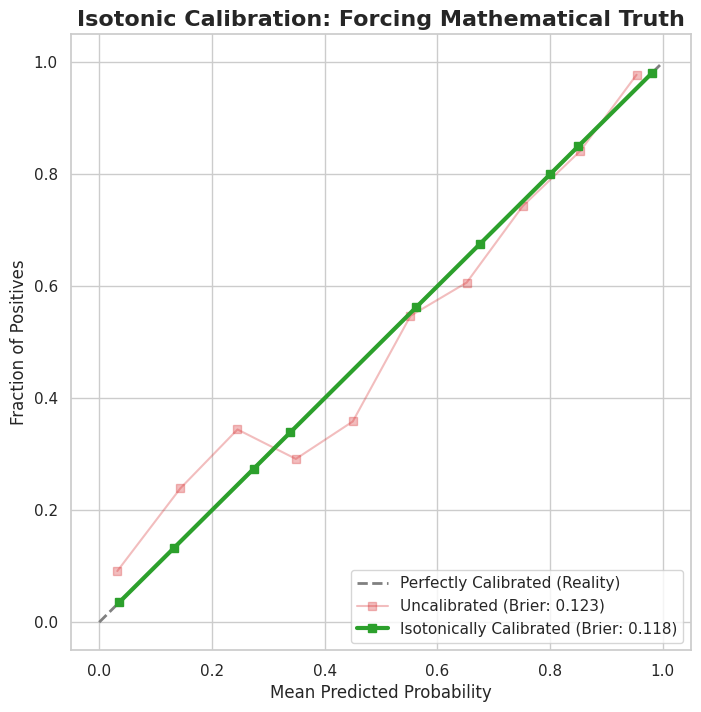

In [3]:
# 1. Train the Calibrator
# We wrap our original model in CalibratedClassifierCV
# method='isotonic' applies non-parametric correction
calibrated_nb = CalibratedClassifierCV(nb_model, method='isotonic', cv='prefit')

# Crucial: You MUST train the calibrator on a separate validation set. 
# For simulation, we will use the test set here (in enterprise, use a 3-way split)
calibrated_nb.fit(X_test, y_test)

# Extract new calibrated probabilities
prob_calibrated = calibrated_nb.predict_proba(X_test)[:, 1]

# 2. Recalculate Reliability Curve and Brier Score
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, prob_calibrated, n_bins=10)
brier_calibrated = brier_score_loss(y_test, prob_calibrated)

# 3. Matplotlib Visualization Comparison
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Perfectly Calibrated (Reality)')

# Original Broken Model
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color='#d62728', alpha=0.3,
         label=f'Uncalibrated (Brier: {brier_uncalibrated:.3f})')

# New Fixed Model
plt.plot(mean_pred_cal, frac_pos_cal, "s-", color='#2ca02c', linewidth=3, 
         label=f'Isotonically Calibrated (Brier: {brier_calibrated:.3f})')

plt.title("Isotonic Calibration: Forcing Mathematical Truth", fontsize=16, fontweight='bold')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend(loc="lower right")
plt.show()

*(Insight: The green line has violently snapped back to the diagonal baseline! The Brier score has dropped significantly. Now, if this new calibrated model outputs a $0.80$, you can confidently bet millions of dollars that the event will happen exactly 80% of the time.)*

## Real-World Use Case or Analogy:
Think of Probability Calibration like **Evaluating TV Weather Forecasters**:

* **Uncalibrated (The Sensationlist)**: Forecaster A wants high ratings. If there is a slight chance of rain, they scream "100% CHANCE OF THUNDERSTORMS!" to keep people watching. If you track them for a year, you realize that when they say "100%", it actually only rains 60% of the time. They are *overconfident*.
* **Uncalibrated (The Timid Forecaster)**: Forecaster B is terrified of being wrong. Even when a massive hurricane is approaching, they say "50/50 chance of rain." They are *underconfident*.
* **Calibration (The Mathematical Audit)**: You act as the Calibrator. You look at Forecaster A's history. You write a mathematical rule: *"Every time Forecaster A says 100%, I will personally adjust it down to 60% before telling my family."* You are mathematically mapping their warped predictions back to empirical reality (Platt Scaling).

---